In [66]:
import pandas as pd

df = pd.read_csv('climate_india_districts_output/climate_india_districts_monthly_data.csv')

In [67]:
df

,tp,e,ro,t2m,stl1,d2m,slt,cvh,cvl,stl2,swvl1,swvl2,year,month,feature
0,0.151340,-0.148008,0.000000,299.62378,301.02777,296.36026,0.00,0.000000,0.000000,301.02420,-0.000005,-4.782852e-06,2000,1,A & N Islands_Nicobars
1,0.118431,-0.121196,0.000000,299.70460,301.11908,295.26120,0.00,0.000000,0.000000,301.11127,-0.000010,4.324813e-06,2000,2,A & N Islands_Nicobars
2,0.209490,-0.105476,0.000000,300.06595,302.18805,296.28100,0.00,0.000000,0.000000,302.17720,0.000005,6.181721e-06,2000,3,A & N Islands_Nicobars
3,0.258236,-0.105481,0.000000,300.06180,302.28190,296.88113,0.00,0.000000,0.000000,302.28226,0.000004,1.230584e-05,2000,4,A & N Islands_Nicobars
4,0.247586,-0.131735,0.000000,300.61984,302.10767,297.42438,0.00,0.000000,0.000000,302.10516,-0.000003,-7.825438e-07,2000,5,A & N Islands_Nicobars
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222619,0.271613,-0.106619,0.052613,301.72134,302.17752,298.65765,2.25,0.317097,0.668795,301.71150,0.396013,4.009045e-01,2023,8,West Bengal_Purulia
222620,0.370721,-0.101135,0.103628,301.32443,302.22028,298.97530,2.25,0.317097,0.668795,301.63550,0.406059,4.077932e-01,2023,9,West Bengal_Purulia
222621,0.080878,-0.099774,0.151273,299.81104,300.35287,295.23170,2.25,0.317097,0.668795,299.81662,0.291241,3.161303e-01,2023,10,West Bengal_Purulia
222622,0.003621,-0.067264,0.033912,296.24124,297.23020,290.93268,2.25,0.317097,0.668795,297.38138,0.176434,2.137261e-01,2023,11,West Bengal_Purulia


In [68]:
df.shape

(222624, 15)

In [69]:
df.columns

Index(['tp', 'e', 'ro', 't2m', 'stl1', 'd2m', 'slt', 'cvh', 'cvl', 'stl2',
       'swvl1', 'swvl2', 'year', 'month', 'feature'],
      dtype='object')

In [79]:
categorical_vars = ['cvh', 'cvl', 'slt']
numerical_vars = ['tp', 'e', 'ro', 't2m', 'stl1', 'd2m', 'stl2', 'swvl1', 'swvl2',] + categorical_vars

In [71]:
print("="*60)
print("TASK 1: Analyzing Categorical Variables (Vegetation & Soil)")
print("="*60)

# Check if categorical variables change over time for each district
def check_temporal_changes(df, district_col='feature'):
    changes_summary = []
    
    for district in df[district_col].unique():
        district_data = df[df[district_col] == district]
        
        for var in categorical_vars:
            unique_values = district_data[var].nunique()
            values_list = district_data[var].unique()
            
            # Check if variable changes over time
            changes_by_year = district_data.groupby('year')[var].nunique()
            has_change = (changes_by_year > 1).any()
            
            changes_summary.append({
                'district': district,
                'variable': var,
                'unique_values': unique_values,
                'values': values_list,
                'changes_over_time': has_change,
                'years_with_change': changes_by_year[changes_by_year > 1].index.tolist()
            })
    
    return pd.DataFrame(changes_summary)

categorical_changes = check_temporal_changes(df)

# Show summary
print("\nCategorical Variables Summary:")
print(f"Total districts analyzed: {df['feature'].nunique()}")

for var in categorical_vars:
    var_data = categorical_changes[categorical_changes['variable'] == var]
    districts_with_change = var_data['changes_over_time'].sum()
    print(f"\n{var}:")
    print(f"  - Districts where {var} changes over time: {districts_with_change}")
    print(f"  - Districts where {var} is constant: {len(var_data) - districts_with_change}")

# Example: Show districts with changes
print("\n--- Districts with categorical changes ---")
districts_with_changes = categorical_changes[categorical_changes['changes_over_time'] == True]
if len(districts_with_changes) > 0:
    print(districts_with_changes.head(10))
else:
    print("No districts show changes in categorical variables over time")


TASK 1: Analyzing Categorical Variables (Vegetation & Soil)

Categorical Variables Summary:
Total districts analyzed: 773

cvh:
  - Districts where cvh changes over time: 1
  - Districts where cvh is constant: 772

cvl:
  - Districts where cvl changes over time: 1
  - Districts where cvl is constant: 772

slt:
  - Districts where slt changes over time: 1
  - Districts where slt is constant: 772

--- Districts with categorical changes ---
               district variable  unique_values                        values  \
999   Ladakh_Leh Ladakh      cvh              2  [0.0013447294, 0.0013104196]   
1000  Ladakh_Leh Ladakh      cvl              2       [0.55879235, 0.5561431]   
1001  Ladakh_Leh Ladakh      slt              2         [2.557227, 2.5631132]   

      changes_over_time years_with_change  
999                True            [2022]  
1000               True            [2022]  
1001               True            [2022]  


In [72]:
# all districts where slt == 2.557227
df[df['slt'] == 2.557227]

,tp,e,ro,t2m,stl1,d2m,slt,cvh,cvl,stl2,swvl1,swvl2,year,month,feature
95904,0.045622,-0.001844,0.001509,252.55011,259.90887,247.20602,2.557227,0.001345,0.558792,260.61260,0.186740,0.258739,2000,1,Ladakh_Leh Ladakh
95905,0.027529,-0.001915,0.001366,250.75507,259.45282,245.76016,2.557227,0.001345,0.558792,259.96730,0.193651,0.264594,2000,2,Ladakh_Leh Ladakh
95906,0.052351,-0.003847,0.001598,255.91821,260.32693,250.24345,2.557227,0.001345,0.558792,260.47632,0.200880,0.267450,2000,3,Ladakh_Leh Ladakh
95907,0.023572,-0.008731,0.008988,261.98883,262.72064,256.63525,2.557227,0.001345,0.558792,262.53967,0.207164,0.272718,2000,4,Ladakh_Leh Ladakh
95908,0.028698,-0.026661,0.086135,269.88547,269.51930,263.36887,2.557227,0.001345,0.558792,268.41263,0.224921,0.285086,2000,5,Ladakh_Leh Ladakh
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96172,0.044892,-0.029455,0.067386,270.48026,271.45520,265.37060,2.557227,0.001345,0.558792,270.67398,0.261197,0.290824,2022,5,Ladakh_Leh Ladakh
96173,0.065299,-0.047014,0.055673,274.03476,276.07108,268.76830,2.557227,0.001345,0.558792,274.99936,0.265427,0.300368,2022,6,Ladakh_Leh Ladakh
96174,0.090935,-0.064863,0.033540,281.20847,282.92874,274.78833,2.557227,0.001345,0.558792,281.57210,0.212082,0.270879,2022,7,Ladakh_Leh Ladakh
96175,0.107686,-0.064861,0.041433,280.03296,282.00198,275.06088,2.557227,0.001345,0.558792,281.41310,0.254844,0.288992,2022,8,Ladakh_Leh Ladakh


In [73]:
df.loc[df['slt'] == 2.5631132, 'slt'] = 2.557227

<Axes: xlabel='slt', ylabel='Count'>

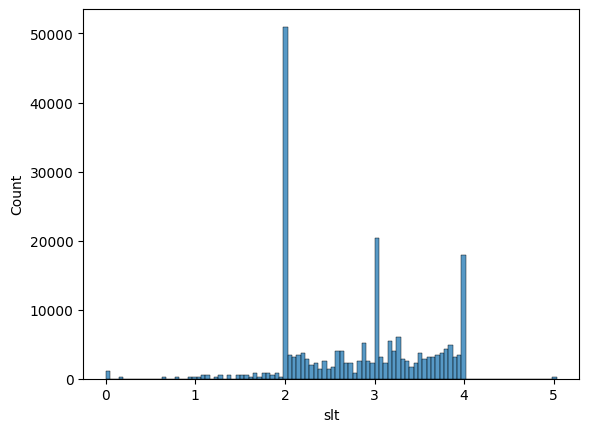

In [74]:
import seaborn as sns

sns.histplot(df['slt'])

In [75]:
df[df['cvl'] == 0.5561431]
# changing them to 0.55879235
df.loc[df['cvl'] == 0.5561431, 'cvl'] = 0.55879235

df[df['cvh'] == 0.0013104196]
# changing them to 0.0013447294
df.loc[df['cvh'] == 0.0013104196, 'cvh'] = 0.0013447294

In [76]:
print("="*60)
print("TASK 1: Analyzing Categorical Variables (Vegetation & Soil)")
print("="*60)

# Check if categorical variables change over time for each district
def check_temporal_changes(df, district_col='feature'):
    changes_summary = []
    
    for district in df[district_col].unique():
        district_data = df[df[district_col] == district]
        
        for var in categorical_vars:
            unique_values = district_data[var].nunique()
            values_list = district_data[var].unique()
            
            # Check if variable changes over time
            changes_by_year = district_data.groupby('year')[var].nunique()
            has_change = (changes_by_year > 1).any()
            
            changes_summary.append({
                'district': district,
                'variable': var,
                'unique_values': unique_values,
                'values': values_list,
                'changes_over_time': has_change,
                'years_with_change': changes_by_year[changes_by_year > 1].index.tolist()
            })
    
    return pd.DataFrame(changes_summary)

categorical_changes = check_temporal_changes(df)

# Show summary
print("\nCategorical Variables Summary:")
print(f"Total districts analyzed: {df['feature'].nunique()}")

for var in categorical_vars:
    var_data = categorical_changes[categorical_changes['variable'] == var]
    districts_with_change = var_data['changes_over_time'].sum()
    print(f"\n{var}:")
    print(f"  - Districts where {var} changes over time: {districts_with_change}")
    print(f"  - Districts where {var} is constant: {len(var_data) - districts_with_change}")

# Example: Show districts with changes
print("\n--- Districts with categorical changes ---")
districts_with_changes = categorical_changes[categorical_changes['changes_over_time'] == True]
if len(districts_with_changes) > 0:
    print(districts_with_changes.head(10))
else:
    print("No districts show changes in categorical variables over time")


TASK 1: Analyzing Categorical Variables (Vegetation & Soil)

Categorical Variables Summary:
Total districts analyzed: 773

cvh:
  - Districts where cvh changes over time: 0
  - Districts where cvh is constant: 773

cvl:
  - Districts where cvl changes over time: 0
  - Districts where cvl is constant: 773

slt:
  - Districts where slt changes over time: 0
  - Districts where slt is constant: 773

--- Districts with categorical changes ---
No districts show changes in categorical variables over time


In [77]:
df

,tp,e,ro,t2m,stl1,d2m,slt,cvh,cvl,stl2,swvl1,swvl2,year,month,feature
0,0.151340,-0.148008,0.000000,299.62378,301.02777,296.36026,0.00,0.000000,0.000000,301.02420,-0.000005,-4.782852e-06,2000,1,A & N Islands_Nicobars
1,0.118431,-0.121196,0.000000,299.70460,301.11908,295.26120,0.00,0.000000,0.000000,301.11127,-0.000010,4.324813e-06,2000,2,A & N Islands_Nicobars
2,0.209490,-0.105476,0.000000,300.06595,302.18805,296.28100,0.00,0.000000,0.000000,302.17720,0.000005,6.181721e-06,2000,3,A & N Islands_Nicobars
3,0.258236,-0.105481,0.000000,300.06180,302.28190,296.88113,0.00,0.000000,0.000000,302.28226,0.000004,1.230584e-05,2000,4,A & N Islands_Nicobars
4,0.247586,-0.131735,0.000000,300.61984,302.10767,297.42438,0.00,0.000000,0.000000,302.10516,-0.000003,-7.825438e-07,2000,5,A & N Islands_Nicobars
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222619,0.271613,-0.106619,0.052613,301.72134,302.17752,298.65765,2.25,0.317097,0.668795,301.71150,0.396013,4.009045e-01,2023,8,West Bengal_Purulia
222620,0.370721,-0.101135,0.103628,301.32443,302.22028,298.97530,2.25,0.317097,0.668795,301.63550,0.406059,4.077932e-01,2023,9,West Bengal_Purulia
222621,0.080878,-0.099774,0.151273,299.81104,300.35287,295.23170,2.25,0.317097,0.668795,299.81662,0.291241,3.161303e-01,2023,10,West Bengal_Purulia
222622,0.003621,-0.067264,0.033912,296.24124,297.23020,290.93268,2.25,0.317097,0.668795,297.38138,0.176434,2.137261e-01,2023,11,West Bengal_Purulia


In [80]:
# Group by district (feature) and month, then average across all years
monthly_aggregated = df.groupby(['feature', 'month'])[numerical_vars].mean().reset_index()

print(f"Original shape: {df.shape}")
print(f"Aggregated shape: {monthly_aggregated.shape}")
monthly_aggregated

Original shape: (222624, 15)
Aggregated shape: (9276, 14)


,feature,month,tp,e,ro,t2m,stl1,d2m,stl2,swvl1,swvl2,cvh,cvl,slt
0,A & N Islands_Nicobars,1,0.155895,-0.145155,0.000000,299.957974,301.395849,296.205143,301.395933,7.828219e-07,9.263556e-07,0.000000,0.000000,0.00
1,A & N Islands_Nicobars,2,0.073241,-0.127951,0.000000,300.347773,301.663718,296.253400,301.655300,-1.457989e-06,-8.020846e-08,0.000000,0.000000,0.00
2,A & N Islands_Nicobars,3,0.107033,-0.118626,0.000000,300.728570,302.288358,296.591939,302.276559,-1.509114e-06,-8.345849e-07,0.000000,0.000000,0.00
3,A & N Islands_Nicobars,4,0.134209,-0.101045,0.000000,300.984711,302.984163,297.179667,302.976795,-2.279712e-07,2.165511e-06,0.000000,0.000000,0.00
4,A & N Islands_Nicobars,5,0.265185,-0.136944,0.000000,300.947370,302.708544,297.735900,302.719828,3.265345e-07,-1.801931e-06,0.000000,0.000000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9271,West Bengal_Purulia,8,0.286655,-0.108605,0.091595,301.316108,301.991658,298.498164,301.356652,4.016572e-01,4.017722e-01,0.317097,0.668795,2.25
9272,West Bengal_Purulia,9,0.232007,-0.106522,0.097131,301.040230,301.816350,298.070948,301.156227,3.893341e-01,3.896617e-01,0.317097,0.668795,2.25
9273,West Bengal_Purulia,10,0.092837,-0.102173,0.072248,299.260643,300.044396,294.979955,299.625393,3.149695e-01,3.254036e-01,0.317097,0.668795,2.25
9274,West Bengal_Purulia,11,0.008047,-0.069953,0.029248,295.191450,296.073610,289.408941,296.285416,2.077455e-01,2.354825e-01,0.317097,0.668795,2.25


In [81]:
monthly_aggregated.to_csv('climate_data_aggregated_by_month_and_district.csv', index=False)